# An introduction to explainable AI with Shapley values

## Learning Objectives

In this lesson we learn to:

1. Show the impact (positive and negative) of features on individual predictions made by the model
2. Explian the Waterfall Plot as visualized
3. Rank features by impact
4. Show features that have infrequently high impact
5. Interpret a SHAP heatmap
6. Zoom in on specific features to inspect their impact and support for specific SHAP-values

We'll be using the [`shap` package](https://shap.readthedocs.io/en/latest/index.html).

## Model-specific methods

For a Decision Tree model: importance is calculated by looking at how many times a feature (like "Square Footage") was used to split the data.

For a Linear Regression model: importance is calculated based on the size of the coefficient assigned to "Square Footage".

However, we can't compare Apples to Oranges. We cannot compare a "split count" to a "coefficient".

## SHAPley Values

**SHAP** forces every model to explain itself in the exact same terms. A feature’s **Shapley value** is its average contribution to the prediction across all possible permutations in which features could be added.

Order is subtracted away (through permutation) because:

- A feature may add a lot **if added early**
- The same feature may add little **if added after correlated features**

**[SHAP (SHapley Additive exPlanations)](https://christophm.github.io/interpretable-ml-book/shap.html)** by Lundberg and Lee (2017) is a method to explain individual predictions.

**Two different models trained on the same data can be compared via**:

- Distribution of SHAP values
- Directional effects (sign consistency)
- Mean absolute SHAP value per feature

When two models have similar metrics, prefer the one with:

- Lower SHAP variance
- Better interpretable features
- Fewer random interactions

## Explaining a linear regression model

Before using Shapley values to explain complicated models, it is helpful to understand how they work for simple models. One of the simplest model types is standard linear regression, and so below we train a linear regression model on the [California housing dataset](https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html). This dataset consists of 20,640 blocks of houses across California in 1990, where our goal is to predict the natural log of the median home price from 8 different features:

1. MedInc - median income in block group
2. HouseAge - median house age in block group
3. AveRooms - average number of rooms per household
4. AveBedrms - average number of bedrooms per household
5. Population - block group population
6. AveOccup - average number of household members
7. Latitude - block group latitude
8. Longitude - block group longitude


In [1]:
import sklearn
import shap

# a classic housing price dataset
X, y = shap.datasets.california(n_points=1000)

# a simple linear model
model = sklearn.linear_model.LinearRegression()
model.fit(X, y)

LinearRegression()

After the model is fitted, we compute it's SHAPley values as follows:


In [2]:
# 100 instances for use as the background distribution
X100 = shap.utils.sample(X, 100)

explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)

ExactExplainer explainer: 1001it [00:10,  5.47it/s]                         


## 1. Show Impact for Individual Predictions: Waterfall Plot

Looking at a giant matrix of numbers isn't very helpful for a human. Let's use a waterfall plot to understand the prediction for just one specific house over the background average.


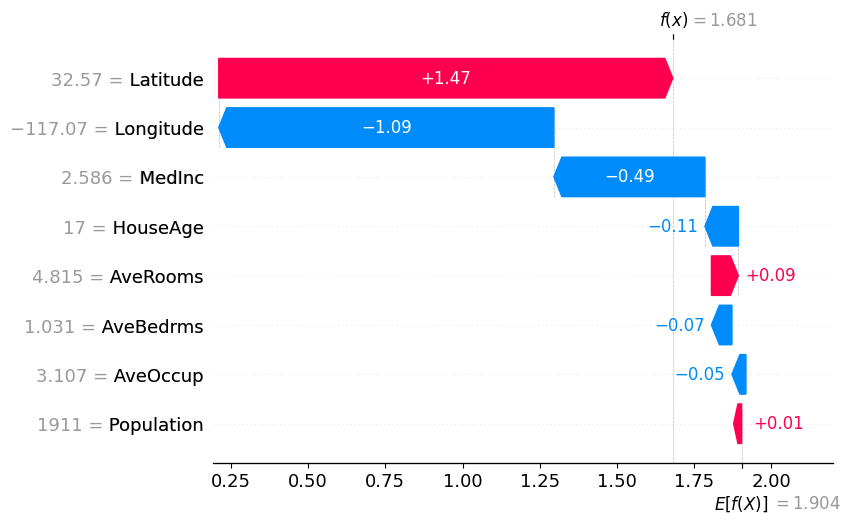

In [3]:
# Choose one house to look at
sample_ind = 20

# Create a waterfall plot to show how features contributed
shap.plots.waterfall(shap_values[sample_ind])

This plot tells a complete story about why the model predicted a certain price for this specific house.

1. **The Base Value:** At the bottom, you'll see a base value ($E[f(X)]$ or expected value). This is what the model would predict if it didn't know *anything* about the house—it is just the average predicted price for all houses in our background data.
2. **The Blue and Red Bars:** Each step up the waterfall represents a feature.
   - **Red bars** mean the feature pushed the predicted price *higher* than the average.
   - **Blue bars** mean the feature pushed the predicted price *lower*.
3. **The Final Output:** The number at the very top ($f(x)$) is the final predicted price for this specific house.

One of the magical things about SHAP values is that they are **additive**. If you take the base value and add up all the SHAP values (the changes from the red and blue bars), you get exactly the final prediction. No missing pieces, no unexplained changes. It splits the credit perfectly among the features!

## Show Feature Impact Across Examples: Bar Plot

### 2.1 Mean Absolute SHAP value

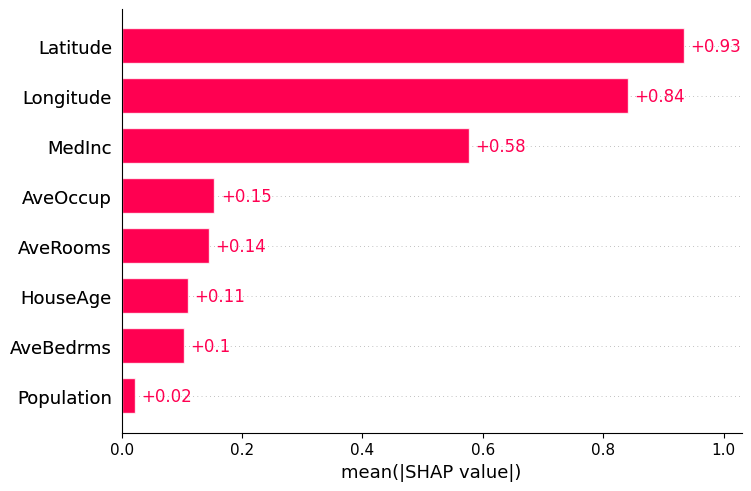

In [4]:
# Show the mean absolute SHAP value for each feature as a bar plot
shap.plots.bar(shap_values)

This bar plot shows the average **absolute** impact of each feature on predictions. In other words, it answers: **"Which features matter most for the model, on average, regardless of whether they push predictions up or down?"**

- The features at the top are the most influential overall.
- Unlike the beeswarm plot, the bar plot doesn't show direction (up or down), but *magnitude* of effect across all predictions.

Use this plot when you want a simple ranking of overall feature importance according to the model.

### Dealing with correlated features

When features are collinear, permuting one feature has little effect on the models performance because it can get the same information from a correlated feature. Note that this is not the case for all predictive models and depends on their underlying implementation.

One way to handle multicollinear features is by performing hierarchical clustering, picking a threshold, and keeping a single feature from each cluster.

In [ ]:
import xgboost

X_adult, y_adult = shap.datasets.adult()

# train XGBoost model
model = xgboost.XGBClassifier(n_estimators=100, max_depth=2)
model.fit(X_adult, y_adult * 1)

# compute SHAP values
background_adult = shap.maskers.Independent(X_adult, max_samples=100)
explainer = shap.Explainer(model, background_adult)
shap_values = explainer(X_adult)

# set a display version of the data to use for plotting (has string values)
shap_values.display_data = shap.datasets.adult(display=True)[0].values

In [12]:
clustering = shap.utils.hclust(X_adult, y_adult)

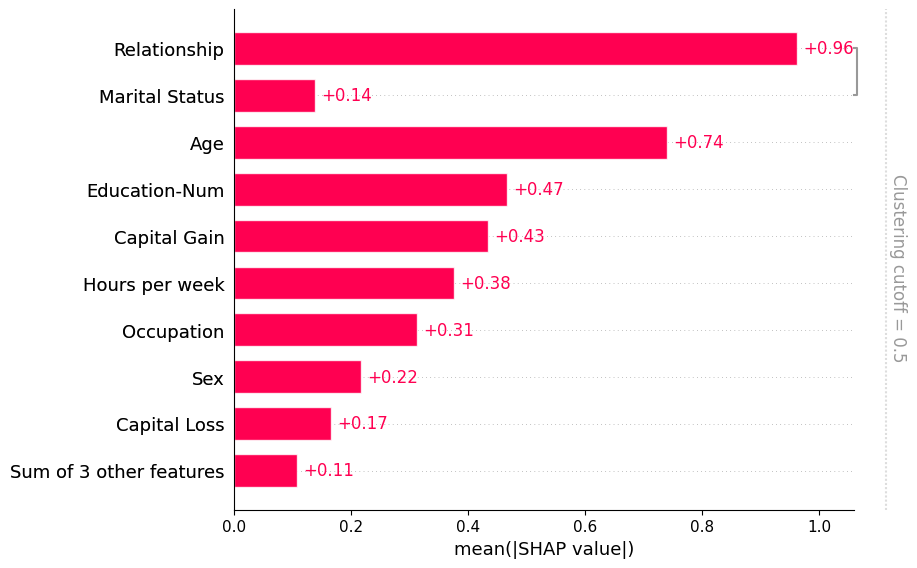

In [13]:
shap.plots.bar(shap_values, clustering=clustering)

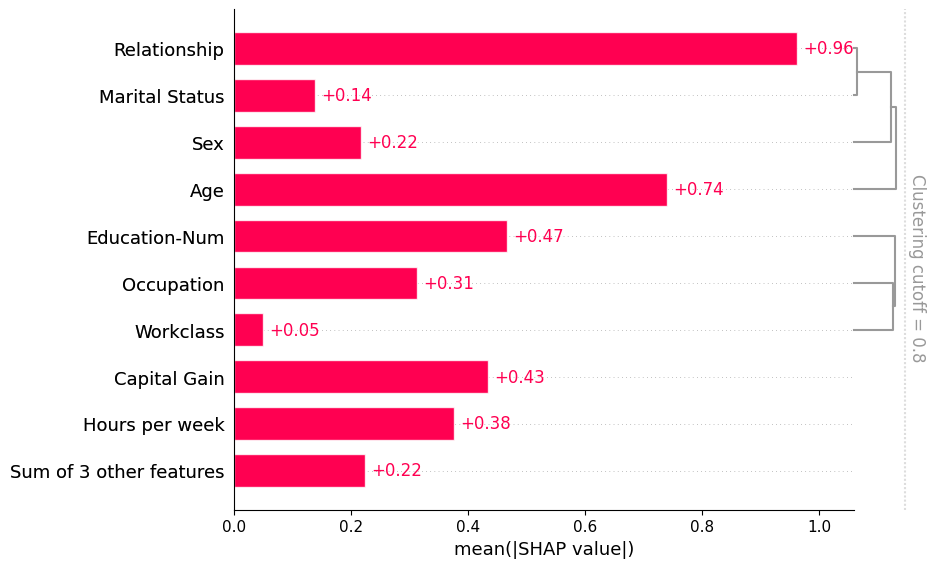

In [14]:
shap.plots.bar(shap_values, clustering=clustering, clustering_cutoff=0.8)

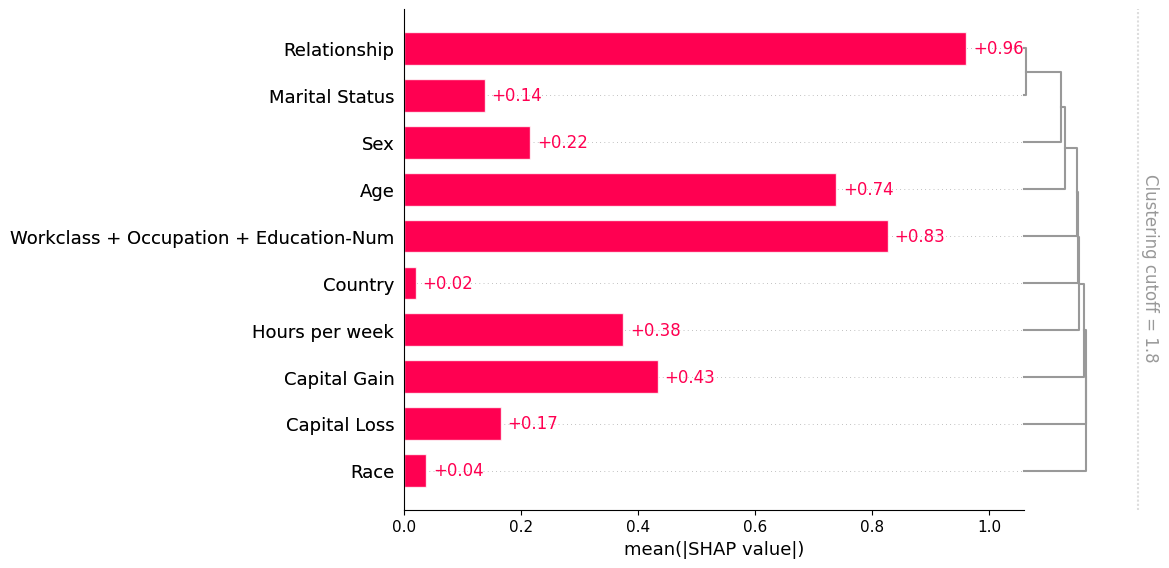

In [15]:
shap.plots.bar(shap_values, clustering=clustering, clustering_cutoff=1.8)

### 2.2 Max Absolute SHAP value

But the mean absolute value is not the only way to create a global measure of feature importance, we can use any number of transforms. Here we show how using the max absolute value highights different features, **since they have infrequent but high magnitude effects**.


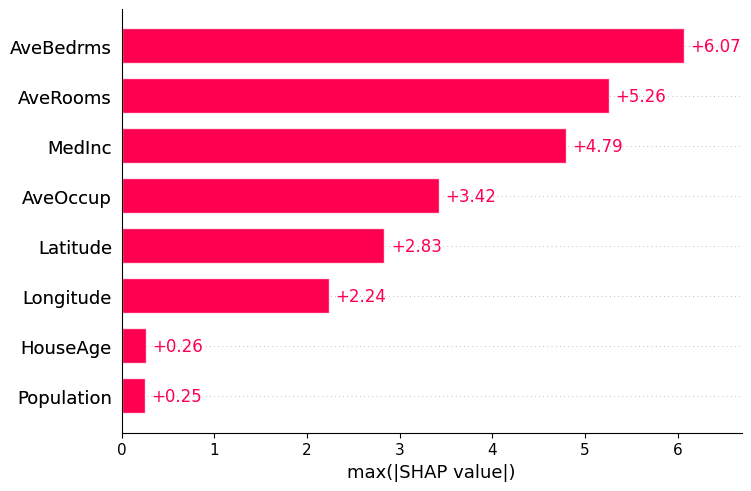

In [5]:
shap.plots.bar(shap_values.abs.max(0))

This plot reveals, for each feature, the **largest possible individual effect** (in absolute terms) it had on any prediction. Use this to identify rare but high-impact features—those that might have an outsized effect for at least some specific cases, even if their average impact (see above) is small.


## 3. SHAP Heatmap

A heatmap for the first 1000 instances:

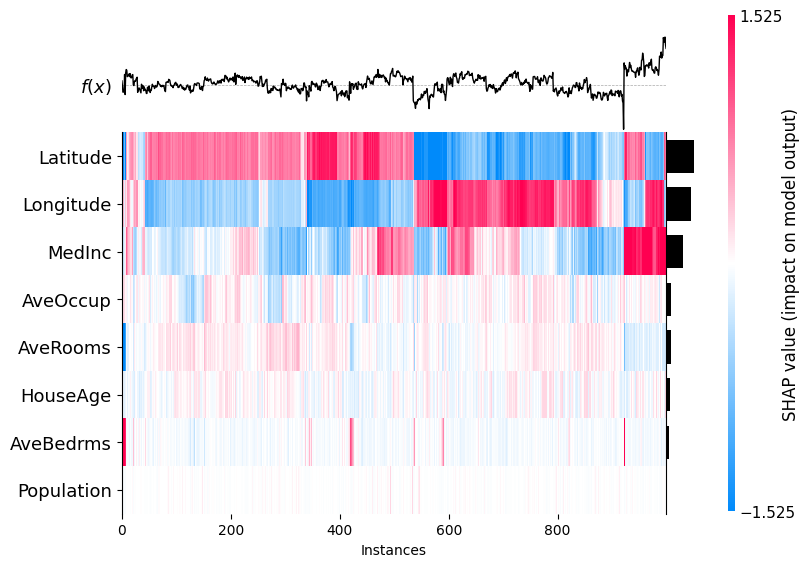

<Axes: xlabel='Instances'>

In [6]:
shap.plots.heatmap(shap_values[:1000])

What the axes mean:

- **The X-Axis (Instances):** Every vertical pixel-wide sliver is one person. We’ve clustered them so that people the model treated similarly are standing next to each other.   
- **The Y-Axis (Features):** These are the variables, ranked from top to bottom by their total influence on the model.
- **The Top Line ($f(x)$):** This is the model's final prediction for each person. When the line is high, the model predicted a high outcome; when it dips, the prediction was low.

What the colors mean: The colors represent the **SHAP value**, which is the specific amount a feature changed the prediction from the average:

- **Red:** That feature pushed the prediction **higher**.
- **Blue:** That feature pushed the prediction **lower**.
- **White:** That feature had **zero impact** for that specific person

## 4. SHAP Value Distribution: Beeswarm Plot

If we are willing to deal with a bit more complexity, we can use a beeswarm plot to summarize the entire distribution of SHAP values for each feature.


### 4.1 SHAP Value Distribution (shown with feature values)


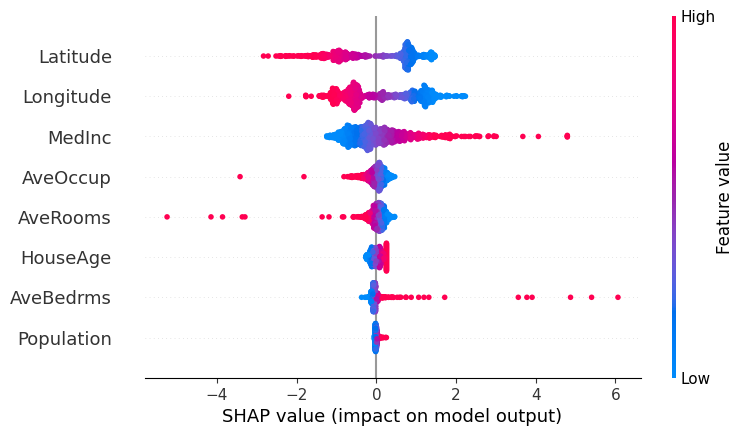

In [7]:
shap.plots.beeswarm(shap_values)

The beeswarm plot displays SHAP values for each feature across all examples, with colors indicating how the SHAP values correlate with feature values:

1. **Each dot** is a single house from the dataset.
2. **Position on the x-axis:** The SHAP value (how much that feature increased or decreased this house's predicted price, compared to the average).
3. **Color:** The feature's actual value for that house (e.g., red for high values, blue for low).
4. **Vertical spread:** Helps show the distribution and "density" of SHAP values for each feature—features with lots of dots far from zero are more influential.

**Interpreting the plot:**  

- Features are sorted by importance (top = more impact).
- If most dots for a feature are far from zero (in either direction), that feature has a big effect on predictions.
- Red dots on the right (positive SHAP) indicate high feature values increase predicted price; blue dots on the left indicate low values decrease it.

This visualization helps you see which features drive your model's predictions—for many houses and all at once.

### 4.2 Mean Absoluate SHAP Value Distribution

We get a compromise between the complexity of the bar plot and the full beeswarm plot by:

1. taking the absolute value and
2. using a solid color


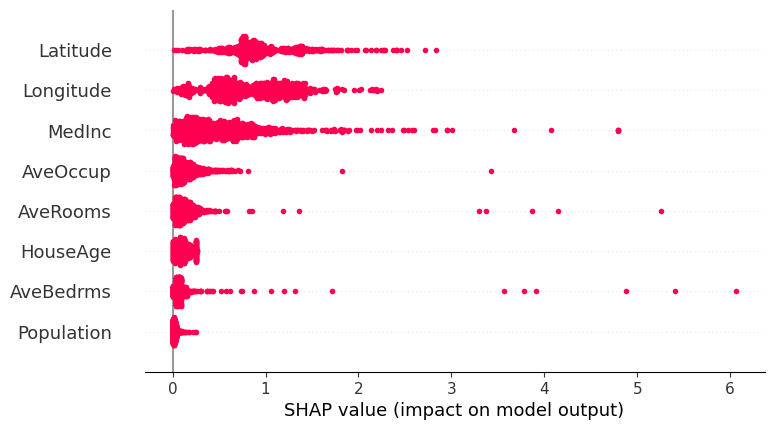

In [8]:
shap.plots.beeswarm(shap_values.abs, color="shap_red")


## 5. SHAP Value for a Single Feature

You can also zoom in on how a single feature affects your model’s prediction. The scatter plot below shows the distribution of SHAP values for the feature across all instances. Each dot represents one data point (e.g., a house in our dataset):

- **X-axis:** The value of the feature for each instance.
- **Y-axis:** The SHAP value, indicating how much impacts the model’s prediction (higher or lower than average).
- **Bottom-plot**: shows the histogram of the feature; the higher, the more confident we are in the corresponding SHAP value on the y-axis

This plot lets you see not just if feature X matters, but *how*:

- for example: whether older houses tend to decrease or increase the predicted outcome
- and whether the effect is consistent (straight line) or varies (curvatures)


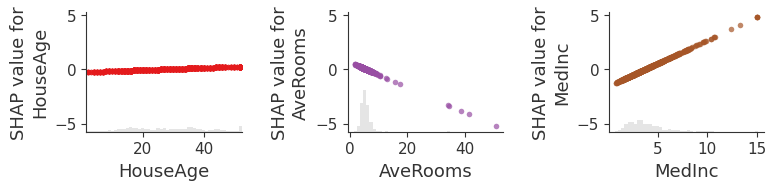

In [9]:
import matplotlib.pyplot as plt

# Choose three features to compare
features = ["HouseAge", "AveRooms", "MedInc"]

fig, axes = plt.subplots(1, 3, figsize=(8, 2), sharey=True)

for i, feature in enumerate(features):
    shap.plots.scatter(
        shap_values[:, feature],
        color=plt.cm.Set1(features.index(feature) / len(features)),
        show=False,
        alpha=0.7,
        ax=axes.flat[i]
    )

plt.tight_layout()
plt.show()

::: {.callout-note}

These are essentially [Partial Dependence Plots](https://christophm.github.io/interpretable-ml-book/pdp.html) which builds on top of [Individual Conditional Expectation curves](https://christophm.github.io/interpretable-ml-book/ice.html) which builds on top of [Ceteris Paribus Plots](https://christophm.github.io/interpretable-ml-book/ceteris-paribus.html).

:::